# MFD2 EDA

MFD2 is not a sentence-level benchmark. It is a lexical resource, so the EDA should focus on category coverage and term organization rather than ordinary row labels or train/test splits.


In [1]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def set_csv_field_limit() -> None:
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit //= 10


set_csv_field_limit()
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)


def find_project_root() -> tuple[Path, Path]:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for data_name in ("Data", "data"):
            data_root = candidate / data_name
            if data_root.exists():
                return candidate, data_root
    raise FileNotFoundError("Could not find project data directory.")


ROOT, DATA_ROOT = find_project_root()
RAW_PATH = DATA_ROOT / "raw/mfd2"
PROCESSED_PATH = DATA_ROOT / "processed/mfd2"

print("Notebook:", "MFD2 EDA")
print("Project root:", ROOT)
print("Raw path:", RAW_PATH)
print("Processed path:", PROCESSED_PATH)


def parse_metadata(value: object) -> dict:
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except Exception:
        try:
            return literal_eval(value)
        except Exception:
            return {}


def preview_frame(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def count_chars(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.len()


def markdown(text: str) -> None:
    display(Markdown(text))


Notebook: MFD2 EDA
Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\mfd2
Processed path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\mfd2


In [2]:
dic_path = next(RAW_PATH.glob("*.dic"))
lines = dic_path.read_text(encoding="utf-8", errors="replace").splitlines()

categories = {}
terms = []
section = 0
for line in lines:
    line = line.strip()
    if not line:
        continue
    if line == "%":
        section += 1
        continue
    if section == 1:
        idx, label = line.split("\t", 1)
        categories[idx] = label
    elif section >= 2:
        term, cat_id = line.split("\t", 1)
        terms.append({"term": term, "category_id": cat_id, "category": categories.get(cat_id, cat_id)})

terms_df = pd.DataFrame(terms)
terms_df[["foundation", "polarity"]] = terms_df["category"].str.split(".", n=1, expand=True)

markdown("### Raw Snapshot")
display(pd.DataFrame({
    "dictionary_files": [len(list(RAW_PATH.glob('*')))],
    "categories": [len(categories)],
    "terms": [len(terms_df)],
    "foundations": [terms_df["foundation"].nunique()],
}))
preview_frame(terms_df)


### Raw Snapshot

,dictionary_files,categories,terms,foundations
0,2,10,2104,5


,term,category_id,category,foundation,polarity
0,compassion,1,care.virtue,care,virtue
1,empathy,1,care.virtue,care,virtue
2,kindness,1,care.virtue,care,virtue
3,caring,1,care.virtue,care,virtue
4,generosity,1,care.virtue,care,virtue


In [3]:
markdown("### Sample Lexicon Entries")
display(terms_df[["term", "category", "foundation", "polarity"]].head(12))


### Sample Lexicon Entries

,term,category,foundation,polarity
0,compassion,care.virtue,care,virtue
1,empathy,care.virtue,care,virtue
2,kindness,care.virtue,care,virtue
3,caring,care.virtue,care,virtue
4,generosity,care.virtue,care,virtue
5,benevolence,care.virtue,care,virtue
6,altruism,care.virtue,care,virtue
7,compassionate,care.virtue,care,virtue
8,nurture,care.virtue,care,virtue
9,gentleness,care.virtue,care,virtue


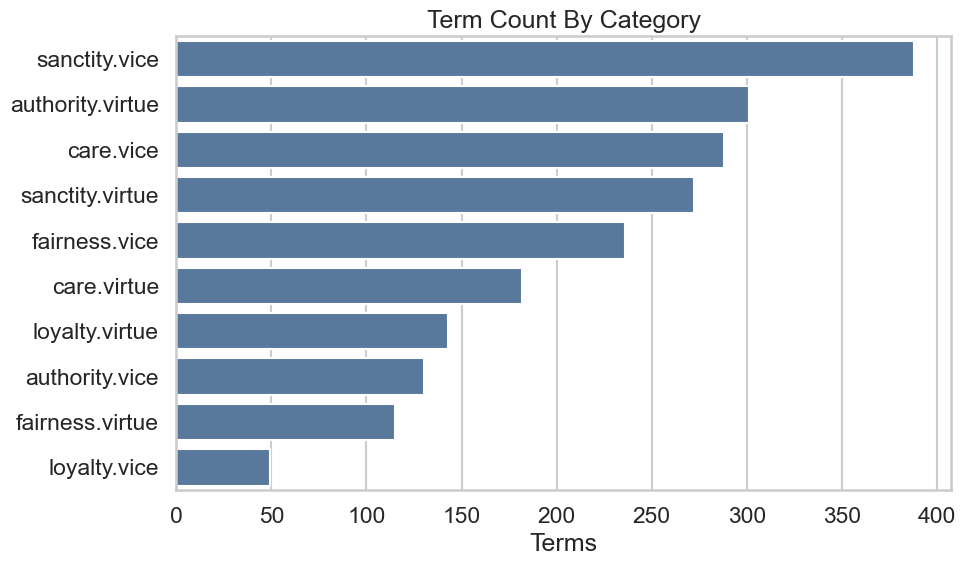

In [4]:
category_counts = terms_df["category"].value_counts().rename_axis("category").reset_index(name="count")
plt.figure(figsize=(10, 6))
sns.barplot(data=category_counts, x="count", y="category", color="#4C78A8")
plt.title("Term Count By Category")
plt.xlabel("Terms")
plt.ylabel("")
plt.tight_layout()
plt.show()


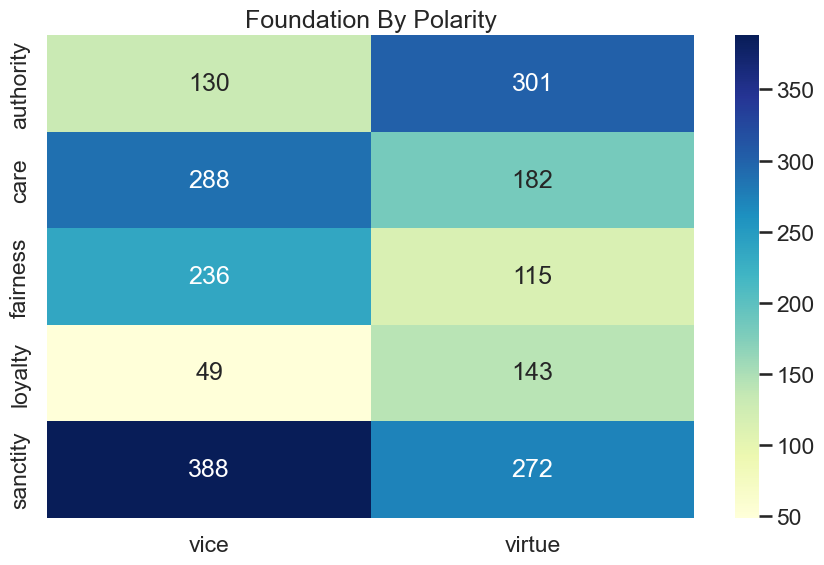

In [5]:
foundation_polarity = pd.crosstab(terms_df["foundation"], terms_df["polarity"])
plt.figure(figsize=(9, 6))
sns.heatmap(foundation_polarity, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Foundation By Polarity")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [6]:
processed_files = [{"file": path.name, "suffix": path.suffix, "bytes": path.stat().st_size} for path in sorted(PROCESSED_PATH.glob("*"))]

markdown("### Processed Snapshot")
display(pd.DataFrame(processed_files))


### Processed Snapshot

,file,suffix,bytes
0,mfd2.dic,.dic,24588
1,mfd2_summary.docx,.docx,36666


In [7]:
comparison_df = pd.DataFrame([
    {"stage": "raw", "resource_type": "dictionary", "sentence_rows": "not applicable"},
    {"stage": "processed", "resource_type": "copied lexical resource", "sentence_rows": "not applicable"},
])
markdown("### Raw vs Processed Comparison")
display(comparison_df)


### Raw vs Processed Comparison

,stage,resource_type,sentence_rows
0,raw,dictionary,not applicable
1,processed,copied lexical resource,not applicable


## Key Takeaways

- MFD2 should be presented as a lexical support resource rather than a normal benchmark dataset.
- The useful EDA questions are about category coverage and term distribution, not label balance or split quality.
- Its role in the project is interpretive and analytical rather than direct model training.
